# Hotel Booking Demand — End-to-End Exploratory Data Analysis

**`Notebook structure`**
1. Setup & Imports
2. Data Loading
3. Initial Inspection
4. Data Quality Assessment
5. Data Cleaning
6. Feature Engineering
7. Univariate Analysis
8. Bivariate Analysis
9. Multivariate / Correlation Analysis
10. Time-Series & Seasonality Analysis
11. Statistical Hypothesis Testing
12. Business Problem 1 — Cancellation Drivers & Risk Flagging
13. Business Problem 2 — Revenue by Channel/Segment
14. Business Problem 3 — Seasonal Demand & Pricing
15. Business Problem 4 — Room Allocation Mismatches
16. Business Problem 5 — Repeat Guest / Loyalty Value
17. Business Problem 6 — Country/Market Prioritization
18. Business Problem 7 — Operational Friction (Waiting List & Booking Changes)
19. Executive Summary & Recommendations


### 1: Importing Libraries

In [13]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Data Loading

Load the raw CSV. Keep a pristine copy (`df_raw`) untouched, and work on a copy (`df`) from here on —
this is standard practice so we can always diff our cleaning steps against the original.

In [14]:
DATA_PATH = "hotel_bookings.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 119,390  |  Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 3: Initial Inspection

In [4]:
df.head(4)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


### Step 4: DATA Quality Assessment

In [16]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_report # This will give us only those Columns who have > 0 null values

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


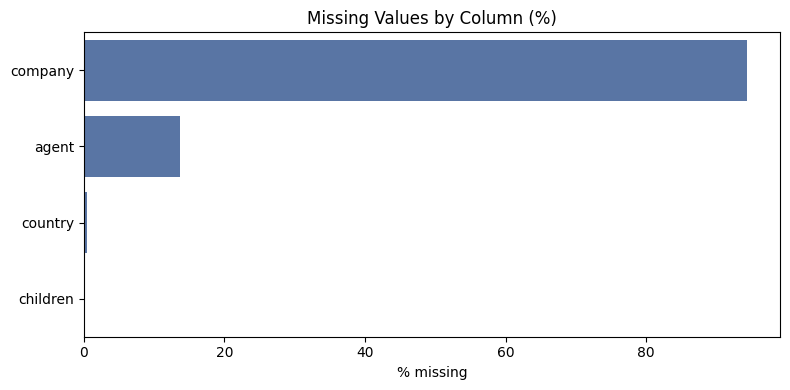

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_report["missing_pct"], y=missing_report.index, color="#4C72B0")
plt.title("Missing Values by Column (%)")
plt.xlabel("% missing")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [18]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dupe_count:,} ({dupe_count/len(df)*100:.1f}% of dataset)")

Fully duplicated rows: 31,994 (26.8% of dataset)


In [20]:
# Sanity checks for logically impossible records
zero_guest_bookings = df[(df["adults"] + df["children"].fillna(0) + df["babies"]) == 0]
print(f"Bookings with zero total guests (likely data errors): {len(zero_guest_bookings):,}")

print(f"\nADR distribution check (top 5 highest values):")
print(df["adr"].sort_values(ascending=False).head(5).to_string())

Bookings with zero total guests (likely data errors): 180

ADR distribution check (top 5 highest values):
48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0


**Findings so far:**
- `company` is missing for the vast majority of bookings, `agent` for a meaningful minority — both are
  reference IDs, not measurements, so imputing them numerically would be meaningless.
- A modest number of duplicate rows exist — common in booking-system exports and worth deciding on
  a case-by-case basis whether to deduplicate (we will, for most aggregate analyses).
- A small number of "zero guest" bookings and one **extreme `adr` outlier** stand out immediately —
  classic hallmark of manual data-entry errors that must be handled before any pricing analysis.

### 5. DATA Cleaning

In [22]:
df_clean = df.copy()

# --- 5.1 Fix dtypes: these are counts/IDs, not continuous floats ---
df_clean["children"] = df_clean["children"].fillna(0).astype(int)
df_clean["agent"] = df_clean["agent"]      # keep as float (NaN = no agent), but flag usage below
df_clean["company"] = df_clean["company"]  # keep as float (NaN = no company), but flag usage below

df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_company"] = df_clean["company"].notna().astype(int)

# --- 5.2 Handle missing country: impute with 'Unknown' rather than dropping ---
df_clean["country"] = df_clean["country"].fillna("Unknown")

# --- 5.3 Remove logically invalid rows: bookings with zero total guests ---
before = len(df_clean)
df_clean = df_clean[(df_clean["adults"] + df_clean["children"] + df_clean["babies"]) > 0]
print(f"Dropped {before - len(df_clean):,} zero-guest rows")

# --- 5.4 Treat the extreme ADR outlier (known data-entry error) ---
before = len(df_clean)
adr_cap = df_clean["adr"].quantile(0.999)
outliers = df_clean[df_clean["adr"] > adr_cap]
print(f"Capping {len(outliers)} extreme ADR outlier(s) above the 99.9th percentile (~{adr_cap:.2f})")
df_clean = df_clean[df_clean["adr"] <= adr_cap]

# --- 5.5 Remove exact duplicate rows for aggregate/statistical analysis ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean):,} duplicate rows")

# --- 5.6 Build a proper arrival_date datetime column ---
month_map = {m: i+1 for i, m in enumerate(
    ["January","February","March","April","May","June","July","August",
     "September","October","November","December"])}
df_clean["arrival_month_num"] = df_clean["arrival_date_month"].map(month_map)
df_clean["arrival_date"] = pd.to_datetime(dict(
    year=df_clean["arrival_date_year"],
    month=df_clean["arrival_month_num"],
    day=df_clean["arrival_date_day_of_month"]
), errors="coerce")

df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"], errors="coerce")

print(f"\nFinal cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Dropped 180 zero-guest rows
Capping 120 extreme ADR outlier(s) above the 99.9th percentile (~326.26)
Dropped 31,979 duplicate rows

Final cleaned shape: 87,111 rows x 36 columns


In [23]:
# Confirm cleanliness
print("Remaining missing values:\n", df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nRemaining duplicates:", df_clean.duplicated().sum())

Remaining missing values:
 agent      12126
company    81874
dtype: int64

Remaining duplicates: 0


### 6. Feature Engineering